In [40]:
import numpy as np
import cv2
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
# download variational autoencoder
!wget http://agentspace.org/download/mnist_cvae_069_encoder.pth
!wget http://agentspace.org/download/mnist_cvae_069_decoder.pth

--2026-01-18 16:48:09--  http://agentspace.org/download/mnist_cvae_069_encoder.pth
Resolving agentspace.org (agentspace.org)... 62.168.101.9
Connecting to agentspace.org (agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/mnist_cvae_069_encoder.pth [following]
--2026-01-18 16:48:09--  https://www.agentspace.org/download/mnist_cvae_069_encoder.pth
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 326621 (319K)
Saving to: ‘mnist_cvae_069_encoder.pth’

mnist_cvae_069_enco 100%[===================>] 318.97K  --.-KB/s    in 0.1s    

2026-01-18 16:48:09 (2.91 MB/s) - ‘mnist_cvae_069_encoder.pth’ saved [326621/326621]

--2026-01-18 16:48:09--  http://agentspace.org/download/mnist_cvae_069_decoder.pth
Resolving agentspace.org (agentspac

In [4]:
# load variational autoencoder
encoder = torch.load('mnist_cvae_069_encoder.pth', weights_only=False, map_location=device)
decoder = torch.load('mnist_cvae_069_decoder.pth', weights_only=False, map_location=device)

In [5]:
encoder.eval()

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): ReLU()
  (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU()
  (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (8): ReLU()
  (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): Flatten(start_dim=1, end_dim=-1)
  (15): Linear(in_features=3136, out_features=2, bias=True)
)

In [6]:
decoder.eval()

Sequential(
  (0): Linear(in_features=2, out_features=1568, bias=True)
  (1): ReLU()
  (2): Unflatten(dim=1, unflattened_size=(32, 7, 7))
  (3): ConvTranspose2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (6): ReLU()
  (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (11): ReLU()
  (12): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (14): Sigmoid()
)

In [7]:
# get datasets
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


In [8]:
# select a subset of classes
classes_to_keep = [0, 6, 9]
class_to_id = {class_: i for i, class_ in enumerate(classes_to_keep)}
print(class_to_id)
id_to_class = {i: class_ for class_, i in class_to_id.items()}
print(id_to_class)

{0: 0, 6: 1, 9: 2}
{0: 0, 1: 6, 2: 9}


In [9]:
class RemappedSubset(Dataset):
    def __init__(self, original_dataset, indices, class_to_new):
        self.original = original_dataset
        self.indices = indices
        self.class_to_new = class_to_new

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x, y = self.original[real_idx]
        new_y = self.class_to_new[int(y)]
        return x, new_y

In [10]:
# create subset
train_indices = [i for i, (_, label) in enumerate(train_dataset) if label in classes_to_keep] # indices for train subset
test_indices = [i for i, (_, label) in enumerate(test_dataset) if label in classes_to_keep] # indices for test subset
train_subset = RemappedSubset(train_dataset, train_indices, class_to_id)
test_subset = RemappedSubset(test_dataset, test_indices, class_to_id)

In [11]:
# test subset dataset
labels = torch.tensor([label for _, label in train_subset])
print(torch.unique(labels))
labels = torch.tensor([label for _, label in test_subset])
print(torch.unique(labels))

tensor([0, 1, 2])
tensor([0, 1, 2])


In [12]:
# get few samples
x_samples = torch.stack([ test_subset[i][0] for i in [0,1,2,3,4,5,6,7,8,9] ])
print(x_samples.shape)

torch.Size([10, 1, 28, 28])


In [13]:
# encode and decode
y_samples = decoder(encoder(x_samples.to(device)))

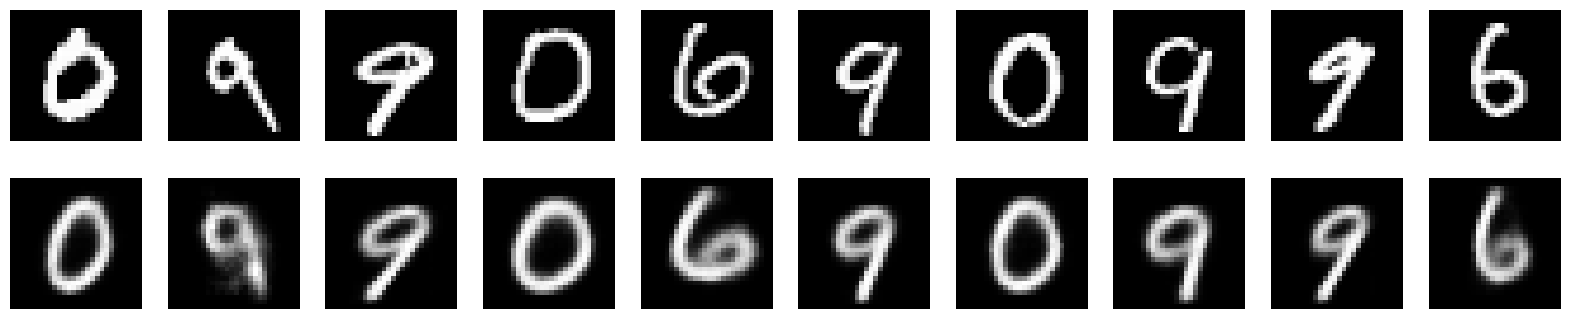

In [84]:
# show the comparison
def show_comparison(x, y):
    plt.figure(figsize=(20, 4))
    for i in range(10):
        input_img = (x_samples[i].squeeze(0).detach().cpu().numpy()*255).astype(np.uint8)
        plt.subplot(2, 10, i+1)
        plt.imshow(input_img, cmap='gray')
        plt.axis('off')
        output_img = (y_samples[i].squeeze(0).detach().cpu().numpy()*255).astype(np.uint8)
        plt.subplot(2, 10, i+1+10)
        plt.imshow(output_img, cmap='gray')
        plt.axis('off')
    plt.show()

show_comparison(x_samples, y_samples)

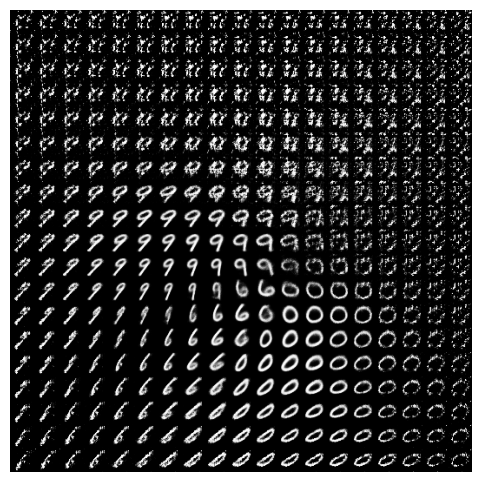

In [65]:
# visualize the latent space
n=20
norm = torch.distributions.Normal(0, 1)
grid_x = 3*norm.icdf(torch.linspace(0.05, 0.95, n-1))
grid_y = 3*norm.icdf(torch.linspace(0.05, 0.95, n-1))

def visualize():
    figure = np.zeros((28 * (n-1), 28 * (n-1)))
    with torch.no_grad():
        for i, yi in enumerate(grid_x):
            for j, xi in enumerate(grid_y):
                z = torch.tensor([[xi, yi]]).float().to('cuda')
                x_decoded = decoder(z)
                digit = x_decoded[0].reshape(28, 28).cpu().numpy()
                figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit
    plt.figure(figsize=(6, 6))
    plt.imshow(figure, cmap='Greys_r')
    plt.axis('off')

visualize()
plt.show()

In [66]:
# manually select representants of 0, 6, 9
representants = [(16,11), (15,6), (8,6)] # (row, col)

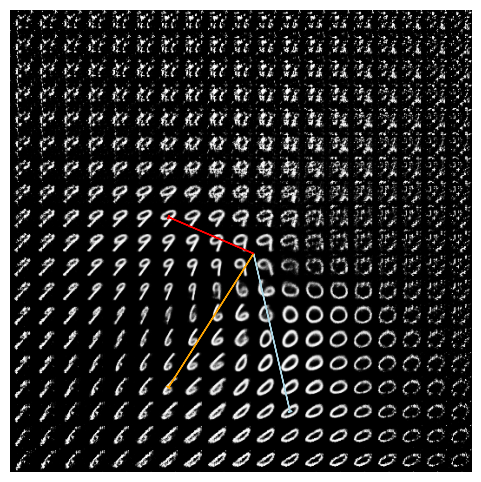

In [127]:
# check and get values
vecs = []
visualize()
colors = ['lightblue', 'orange', 'red']
for k, representant in enumerate(representants):
    i, j = representant
    color = colors[k]
    plt.arrow(10*28, 10*28, 28*(j-10)+14, 28*(i-10)+14, head_width=5, head_length=0, fc=color, ec=color)
    vecs.append((grid_y[j].item(),grid_x[i].item()))
plt.show()

In [128]:
vecs = torch.tensor(vecs).float().to(device)
vecs

tensor([[ 0.7600,  3.1093],
        [-1.1560,  2.5249],
        [-1.1560, -0.3770]], device='cuda:0')

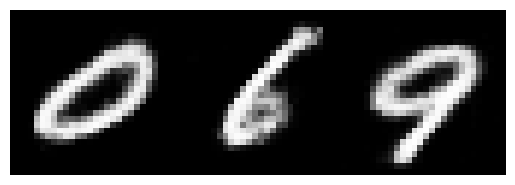

In [129]:
digits = decoder(vecs).detach().cpu().reshape(-1,28,28).numpy()
plt.imshow(np.concatenate(digits, axis=1), cmap='Greys_r')
plt.axis('off')
plt.show()

In [ ]:
def plane_to_sphere_torch(xy, r=5.0, R=1.0):
    x, y = xy[:,0], xy[:,1]
    xmin, xmax, ymin, ymax = -r, r, -r, r
    theta = 2 * math.pi * (x - xmin) / (xmax - xmin)   # [0, 2π]
    phi   = math.pi * (y - ymin) / (ymax - ymin)       # [0, π]
    X = R * torch.sin(phi) * torch.cos(theta)
    Y = R * torch.sin(phi) * torch.sin(theta)
    Z = R * torch.cos(phi)
    return torch.stack([X, Y, Z], dim=1)

In [130]:
keys = vecs.detach().clone()
keys

tensor([[ 0.7600,  3.1093],
        [-1.1560,  2.5249],
        [-1.1560, -0.3770]], device='cuda:0')

In [131]:
values = vecs[[0,2,1]].detach().clone()
values

tensor([[ 0.7600,  3.1093],
        [-1.1560, -0.3770],
        [-1.1560,  2.5249]], device='cuda:0')

In [132]:
# attention
def att(queries, keys, values, scale=1.0):
    coeffs = torch.softmax(queries @ keys.t() / scale,dim=1)
    print(coeffs)
    return coeffs @ values

In [133]:
query = keys[1].unsqueeze(0)

In [134]:
query

tensor([[-1.1560,  2.5249]], device='cuda:0')

In [135]:
query@ keys.t()

tensor([[6.9720, 7.7112, 0.3844]], device='cuda:0')

In [139]:
torch.softmax(query @ keys.t() / 0.05, dim=1)

tensor([[3.7964e-07, 1.0000e+00, 0.0000e+00]], device='cuda:0')

In [140]:
torch.softmax(query @ keys.t() / 0.05, dim=1) @ values

tensor([[-1.1560, -0.3770]], device='cuda:0')

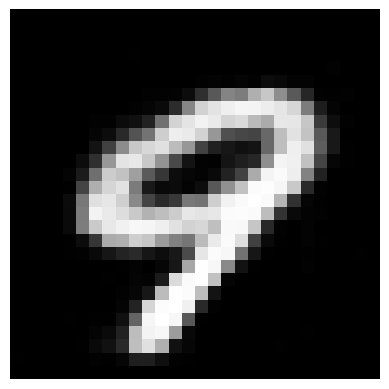

In [144]:
plt.imshow(decoder(torch.softmax(query @ keys.t() / 0.05, dim=1) @ values).detach().cpu().reshape(28,28).numpy(), cmap='Greys_r')
plt.axis('off')
plt.show()

In [141]:
att(query, keys, values, scale=0.05)

tensor([[3.7964e-07, 1.0000e+00, 0.0000e+00]], device='cuda:0')


tensor([[-1.1560, -0.3770]], device='cuda:0')

In [142]:
# encode, attend and decode
y_samples = decoder(att(encoder(x_samples.to(device)),keys,values,scale=0.001))

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 5.8562e-30],
        [1.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


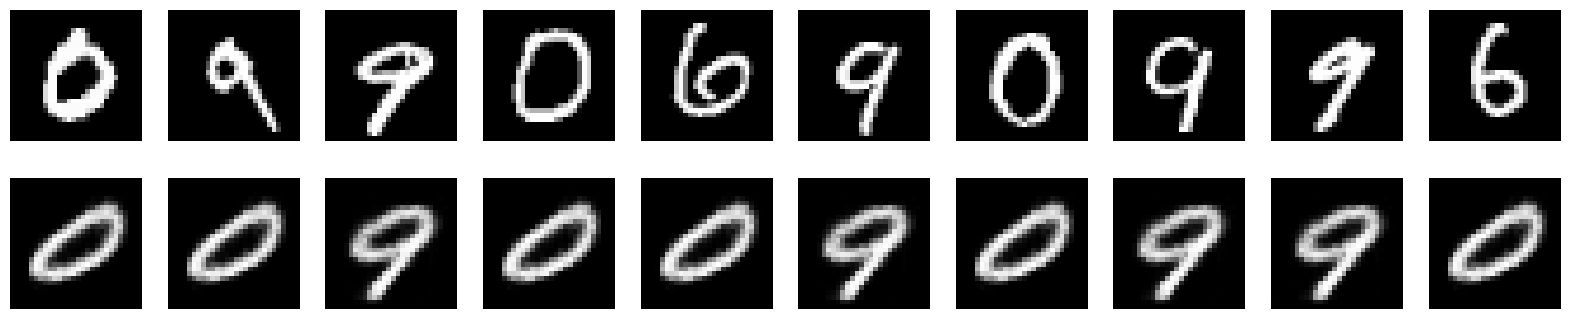

In [143]:
show_comparison(x_samples, y_samples)